In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
# El dataset contiene los porcentajes de retorno diario de entrega de los diferentes ETFs
#ETFs (Fondos cotizados)

#Algunas acciones de empresas en estos sectores:
# - Sector tecnológico: QQQ, XLK
# - Sector energetico: XLE, USO
# - Sector de consumo: XLY, XLP
# - Sector de salud: XLV
# - Sector financiero: XLF
# - Sector de materias primas: XLB

df = pd.read_csv('./etfs.csv')
df

,XLI,QQQ,SPY,DIA,GLD,VXX,USO,IWM,XLE,XLY,XLU,XLB,XTL,XLV,XLP,XLF,XLK
0,-0.376098,0.096313,0.028223,-0.242796,0.419998,-10.400000,0.000000,0.534641,0.028186,0.095759,0.098311,-0.093713,0.019076,-0.009529,0.313499,0.018999,0.075668
1,0.376099,0.481576,0.874936,0.728405,0.490006,-3.520000,0.250000,0.926067,0.995942,0.000000,-0.044686,0.337373,0.000000,0.000000,0.129087,0.104492,0.236462
2,0.150440,0.096313,-0.103487,0.149420,0.239991,6.560000,-0.070000,-0.171848,-0.460387,0.306431,-0.151938,0.103086,0.019072,-0.142955,-0.073766,-0.142490,0.066211
3,-0.141040,-0.491201,0.018819,-0.205449,-0.519989,-8.800000,-0.180000,-0.229128,0.206706,0.153214,0.080437,0.018744,-0.429213,-0.095304,0.119865,0.066495,-0.227003
4,0.244465,-0.048160,-0.056445,-0.168094,0.429992,-0.480000,0.459999,-0.190939,-0.234892,-0.201098,-0.035751,-0.168687,0.000000,0.352630,-0.064548,0.018999,0.009457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
749,-0.379997,-0.669998,-1.270004,-1.398679,0.010002,0.279999,-0.069999,-0.497896,-0.750000,-0.200005,-0.309997,-0.059997,-0.229999,0.189994,-0.279999,-0.220002,-0.330002
750,-0.040001,-0.700004,-0.389999,-0.079926,0.360001,-0.020001,0.189999,-0.587512,0.259995,-0.010002,0.340000,-0.290001,-0.280002,-0.220001,0.029998,-0.030001,-0.330002
751,-0.590000,-1.320000,-2.580002,-1.918189,0.260002,1.829999,-0.080000,-2.280327,-0.500000,-1.089996,-0.160000,-0.769996,-0.700001,-1.180000,-0.500000,-0.330000,-0.450000
752,-0.480000,-0.419998,-1.369996,-1.168887,0.130005,0.889999,0.139999,-0.338568,-0.169998,-0.430001,-0.310001,-0.270001,0.259999,-0.510002,-0.580002,-0.150002,-0.269996


In [3]:
df.corr()

,XLI,QQQ,SPY,DIA,GLD,VXX,USO,IWM,XLE,XLY,XLU,XLB,XTL,XLV,XLP,XLF,XLK
XLI,1.000000,0.785865,0.888865,0.869680,0.056554,-0.468196,0.236881,0.782380,0.650054,0.798080,0.380809,0.784144,0.374000,0.663022,0.600424,0.787340,0.777773
QQQ,0.785865,1.000000,0.908995,0.834440,0.043553,-0.470555,0.199492,0.810158,0.560044,0.839701,0.346667,0.713463,0.421790,0.775392,0.614806,0.752771,0.945126
SPY,0.888865,0.908995,1.000000,0.953726,0.078722,-0.547074,0.272069,0.833937,0.713300,0.887028,0.481928,0.826053,0.406181,0.811269,0.744466,0.883616,0.886588
DIA,0.869680,0.834440,0.953726,1.000000,0.051523,-0.511327,0.256793,0.758012,0.658311,0.847043,0.463364,0.787415,0.383928,0.771044,0.753725,0.860556,0.842757
GLD,0.056554,0.043553,0.078722,0.051523,1.000000,-0.107488,0.216563,0.070110,0.188625,0.017467,0.121611,0.184366,-0.042233,-0.010200,0.033047,0.043039,0.053022
VXX,-0.468196,-0.470555,-0.547074,-0.511327,-0.107488,1.000000,-0.195397,-0.448942,-0.448474,-0.474756,-0.260395,-0.470890,-0.205661,-0.380925,-0.416913,-0.514365,-0.477258
USO,0.236881,0.199492,0.272069,0.256793,0.216563,-0.195397,1.000000,0.249799,0.525943,0.183275,0.113182,0.324166,0.078796,0.119500,0.116857,0.221760,0.225962
IWM,0.782380,0.810158,0.833937,0.758012,0.070110,-0.448942,0.249799,1.000000,0.586991,0.779750,0.325003,0.701533,0.387274,0.664288,0.537065,0.756282,0.760438
XLE,0.650054,0.560044,0.713300,0.658311,0.188625,-0.448474,0.525943,0.586991,1.000000,0.578956,0.337942,0.689778,0.260463,0.454457,0.413486,0.599129,0.559324
XLY,0.798080,0.839701,0.887028,0.847043,0.017467,-0.474756,0.183275,0.779750,0.578956,1.000000,0.366827,0.721232,0.370299,0.702860,0.663055,0.782053,0.772189


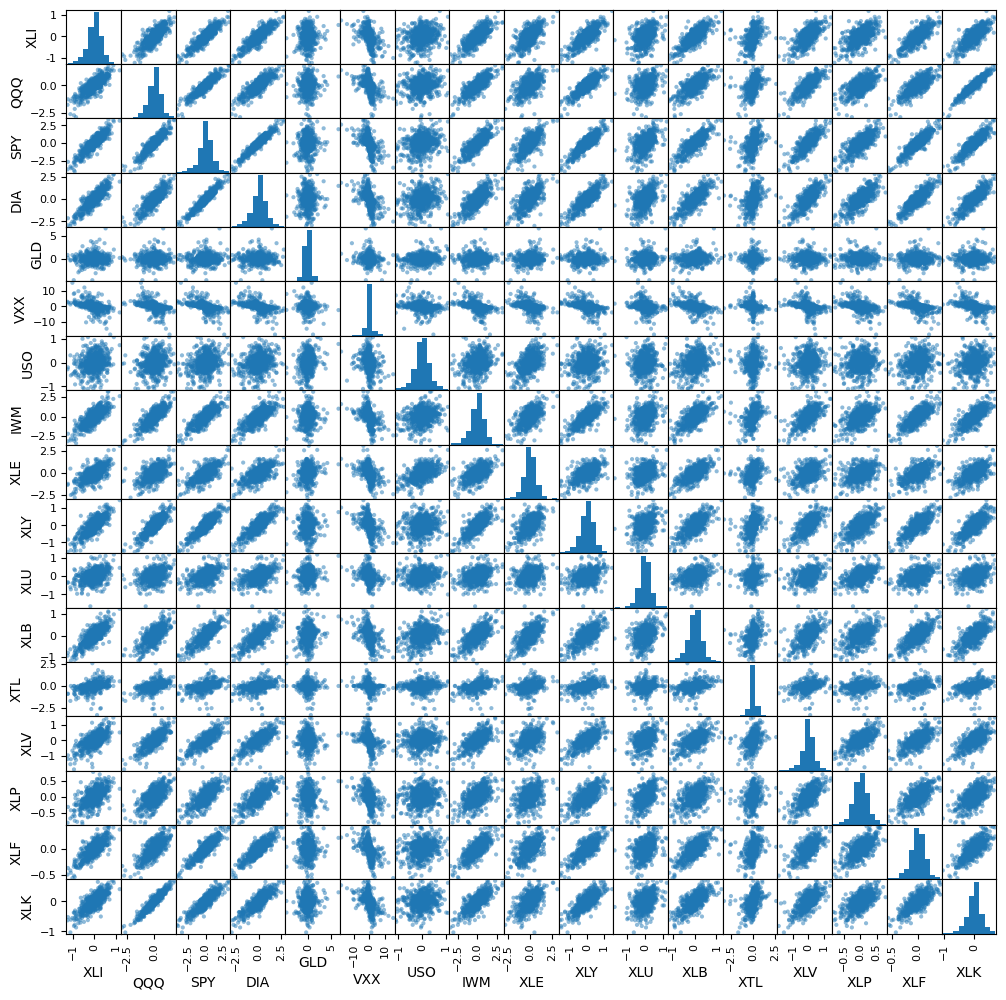

In [4]:
pd.plotting.scatter_matrix(df, figsize=(12,12));

### Regresión lineal para el caso SPY usando como covariable QQQ

El modelo de regresión lineal es el siguiente:
$$\hat{SPY}=\beta_0+\beta_1 \cdot QQQ$$

Text(-3, 0.5, 'Pearson = 0.909')

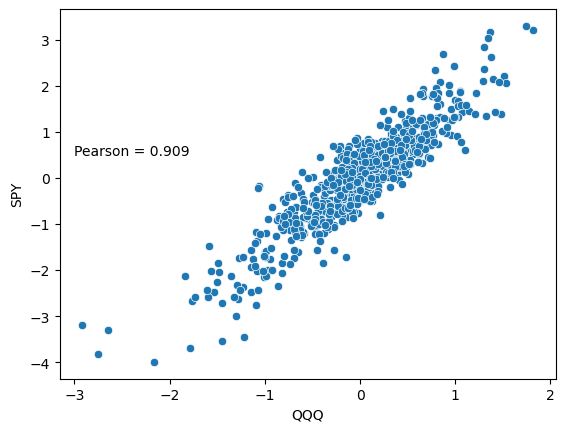

In [29]:
ax = sns.scatterplot(data=df, x= 'QQQ', y='SPY')
coef = df['QQQ'].corr(df['SPY'])
plt.text(-3, .5, f'Pearson = {coef:.3f}')

In [6]:
# Variable de entrada al modelo (variable predictora)
x = df["QQQ"].to_numpy().reshape(-1,1) 
# Variable a predecir
y = df["SPY"].to_numpy().reshape(-1,1) 

print(x.shape)
print(y.shape)

(754, 1)
(754, 1)


In [7]:
mod_lin = LinearRegression()

In [8]:
mod_lin.fit(x,y)

LinearRegression()

In [9]:
# Los parámetros
beta_0 = mod_lin.intercept_[0] # beta_0
beta_1 = mod_lin.coef_[0][0] # beta_1

print('Parámetros del modelo:')
print(f"\tbeta_0 = {beta_0}")
print(f"\tbeta_1 = {beta_1}")

Parámetros del modelo:
	beta_0 = 0.021341792557340207
	beta_1 = 1.5281742261349118


El modelo tiene la forma:
$$\hat{SPY}=0.021+1.528\cdot QQQ$$

La pendiente, que esta definida por el parámetro $\beta_1$ tiene un valor de 1.528. Interpretación:

- Por cada porcentaje de retorno diario de entrega del sector tecnológico (QQQ) se obtendrá un 1.528 porcentaje de retorno diario de entrega en fondos cotizados

Al analizar el valor de $\beta_0$, es decir sin un porcentaje de retorno diario de entrega en el sector tecnológico, obtenemos un 0.021 de porcentaje de retorno diario de entrega en fondos cotizados

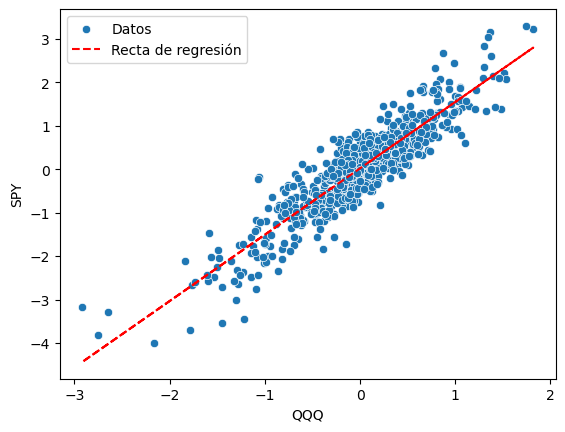

In [10]:
# Datos
fig, ax = plt.subplots()
sns.scatterplot(df, x="QQQ", y="SPY", label='Datos', ax=ax)

# Sobreponer la recta de regresión
ax.plot(x, beta_0 + beta_1*x, label='Recta de regresión', linestyle='--', color="red")
plt.legend();

### Regresión lineal para el caso SPY usando como covariable DIA

El modelo de regresión lineal es el siguiente:
$$\hat{SPY}=\beta_0+\beta_1 \cdot DIA$$

Text(-3, 0.5, 'Pearson = 0.954')

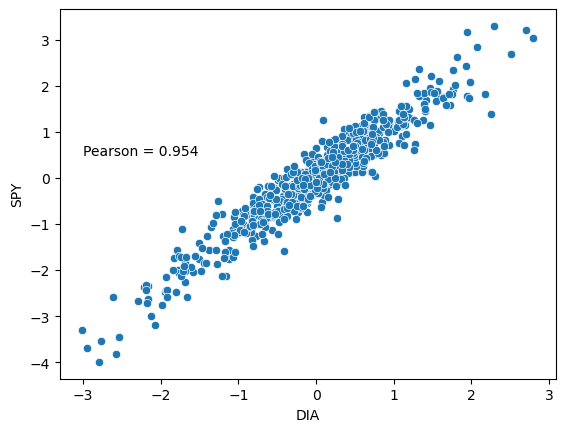

In [30]:
ax = sns.scatterplot(data=df, x= 'DIA', y='SPY')
coef = df['DIA'].corr(df['SPY'])
plt.text(-3, .5, f'Pearson = {coef:.3f}')

In [12]:
# Variable de entrada al modelo (variable predictora)
x = df["DIA"].to_numpy().reshape(-1,1) 
# Variable a predecir
y = df["SPY"].to_numpy().reshape(-1,1) 

print(x.shape)
print(y.shape)

(754, 1)
(754, 1)


In [13]:
mod_lin = LinearRegression()

In [14]:
mod_lin.fit(x,y)

LinearRegression()

In [15]:
# Los parámetros
beta_0 = mod_lin.intercept_[0] # beta_0
beta_1 = mod_lin.coef_[0][0] # beta_1

print('Parámetros del modelo:')
print(f"\tbeta_0 = {beta_0}")
print(f"\tbeta_1 = {beta_1}")

Parámetros del modelo:
	beta_0 = 0.01054339377890805
	beta_1 = 1.150215603447456


El modelo tiene la forma:
$$\hat{SPY}=0.0105+1.1502\cdot DIA$$

La pendiente, que esta definida por el parámetro $\beta_1$ tiene un valor de 1.1502. Interpretación:

- Por cada porcentaje de retorno diario de entrega del indice de mercado amplío (DIA) se obtendrá un 1.1502 porcentaje de retorno diario de entrega en fondos cotizados

Al analizar el valor de $\beta_0$, es decir sin un porcentaje de retorno diario de entrega en el indice de mercado amplío, obtenemos un 0.0105 de porcentaje de retorno diario de entrega en fondos cotizados

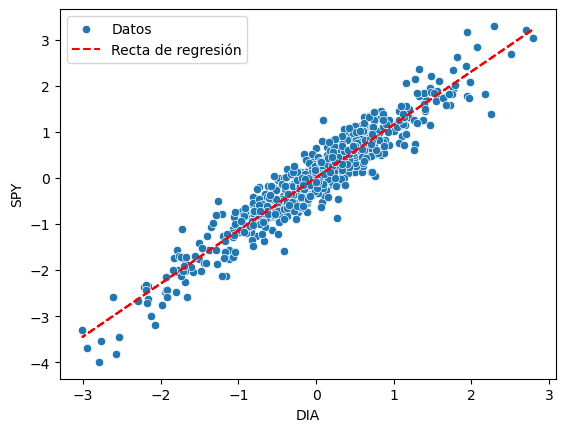

In [16]:
# Datos
fig, ax = plt.subplots()
sns.scatterplot(df, x="DIA", y="SPY", label='Datos', ax=ax)

# Sobreponer la recta de regresión
ax.plot(x, beta_0 + beta_1*x, label='Recta de regresión', linestyle='--', color="red")
plt.legend();

### Regresión lineal para el caso SPY usando como covariable XLI

El modelo de regresión lineal es el siguiente:
$$\hat{SPY}=\beta_0+\beta_1 \cdot XLI$$

Text(-1, 0.5, 'Pearson = 0.889')

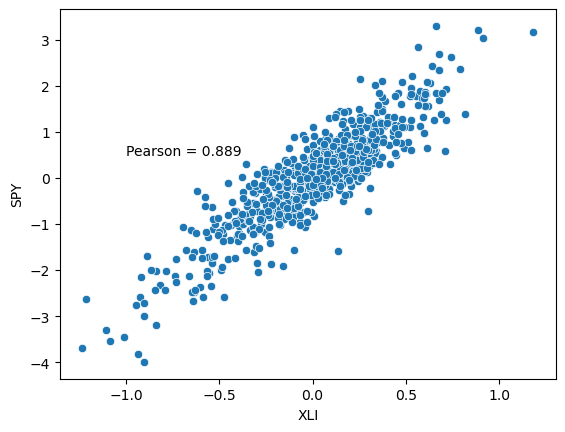

In [31]:
ax = sns.scatterplot(data=df, x= 'XLI', y='SPY')
coef = df['XLI'].corr(df['SPY'])
plt.text(-1, .5, f'Pearson = {coef:.3f}')

In [18]:
# Variable de entrada al modelo (variable predictora)
x = df["XLI"].to_numpy().reshape(-1,1) 
# Variable a predecir
y = df["SPY"].to_numpy().reshape(-1,1) 

print(x.shape)
print(y.shape)

(754, 1)
(754, 1)


In [19]:
mod_lin = LinearRegression()

In [20]:
mod_lin.fit(x,y)

LinearRegression()

In [21]:
# Los parámetros
beta_0 = mod_lin.intercept_[0] # beta_0
beta_1 = mod_lin.coef_[0][0] # beta_1

print('Parámetros del modelo:')
print(f"\tbeta_0 = {beta_0}")
print(f"\tbeta_1 = {beta_1}")

Parámetros del modelo:
	beta_0 = 0.0162668783249378
	beta_1 = 2.720536402107371


El modelo tiene la forma:
$$\hat{SPY}=0.0162+2.7205\cdot XLI$$

La pendiente, que esta definida por el parámetro $\beta_1$ tiene un valor de 2.7205. Interpretación:

- Por cada porcentaje de retorno diario de entrega del indice en el sector industrial (XLI) se obtendrá un 2.7205 porcentaje de retorno diario de entrega en fondos cotizados

Al analizar el valor de $\beta_0$, es decir sin un porcentaje de retorno diario de entrega en el indice de mercado amplío, obtenemos un 0.0162 de porcentaje de retorno diario de entrega en fondos cotizados

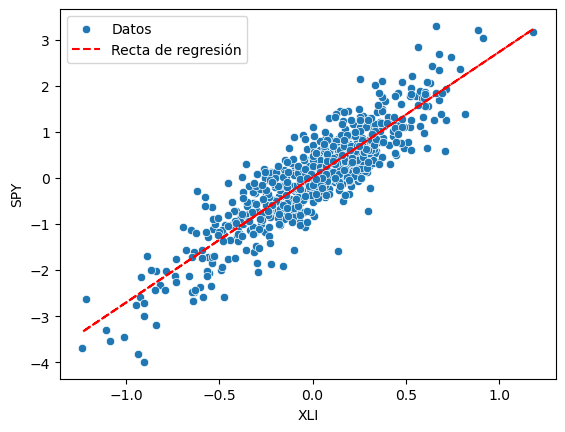

In [22]:
# Datos
fig, ax = plt.subplots()
sns.scatterplot(df, x="XLI", y="SPY", label='Datos', ax=ax)

# Sobreponer la recta de regresión
ax.plot(x, beta_0 + beta_1*x, label='Recta de regresión', linestyle='--', color="red")
plt.legend();

### Regresión lineal para el caso SPY usando como covariable XLY

El modelo de regresión lineal es el siguiente:
$$\hat{SPY}=\beta_0+\beta_1 \cdot XLY$$

Text(-1.6, 0.5, 'Pearson = 0.887')

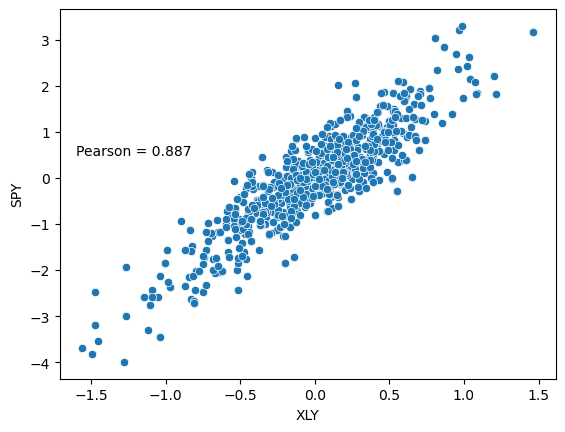

In [32]:
ax = sns.scatterplot(data=df, x= 'XLY', y='SPY')
coef = df['XLY'].corr(df['SPY'])
plt.text(-1.6, .5, f'Pearson = {coef:.3f}')

In [24]:
# Variable de entrada al modelo (variable predictora)
x = df["XLY"].to_numpy().reshape(-1,1) 
# Variable a predecir
y = df["SPY"].to_numpy().reshape(-1,1) 

print(x.shape)
print(y.shape)

(754, 1)
(754, 1)


In [25]:
mod_lin = LinearRegression()

In [26]:
mod_lin.fit(x,y)

LinearRegression()

In [27]:
# Los parámetros
beta_0 = mod_lin.intercept_[0] # beta_0
beta_1 = mod_lin.coef_[0][0] # beta_1

print('Parámetros del modelo:')
print(f"\tbeta_0 = {beta_0}")
print(f"\tbeta_1 = {beta_1}")

Parámetros del modelo:
	beta_0 = 0.009917896436603325
	beta_1 = 2.1207442151254954


El modelo tiene la forma:
$$\hat{SPY}=0.0099+2.1207\cdot XLY$$

La pendiente, que esta definida por el parámetro $\beta_1$ tiene un valor de 2.1207. Interpretación:

- Por cada porcentaje de retorno diario de entrega del indice en el sector de consumo (XLY) se obtendrá un 2.1207 porcentaje de retorno diario de entrega en fondos cotizados

Al analizar el valor de $\beta_0$, es decir sin un porcentaje de retorno diario de entrega en el indice de mercado amplío, obtenemos un 0.0099 de porcentaje de retorno diario de entrega en fondos cotizados

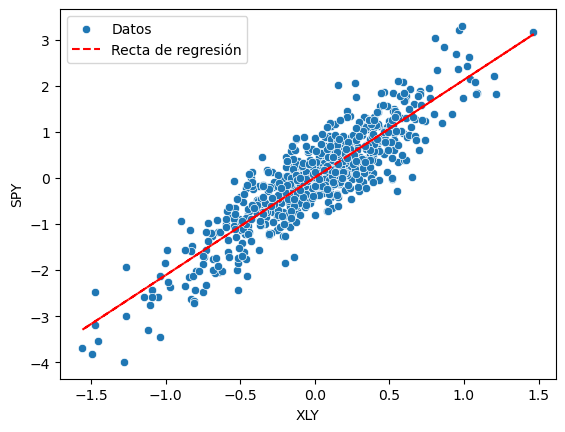

In [28]:
# Datos
fig, ax = plt.subplots()
sns.scatterplot(df, x="XLY", y="SPY", label='Datos', ax=ax)

# Sobreponer la recta de regresión
ax.plot(x, beta_0 + beta_1*x, label='Recta de regresión', linestyle='--', color="red")
plt.legend();